In [ ]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 12.5 MB/s eta 0:00:00


In [ ]:
# ── Step 0: GPU Check + Install ──────────────────────────────────────────
import subprocess

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print("✅ GPU detected:")
    print(result.stdout)
else:
    print("❌ No GPU found!")
    print("   → Go to Runtime → Change runtime type → Hardware accelerator → T4 GPU")
    print("   → Then re-run this cell")

# Install packages
!pip install -q ultralytics roboflow albumentations opencv-python-headless tqdm pyyaml matplotlib
print("\n✅ All packages installed.")

✅ GPU detected:
Sat Mar 21 06:10:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------------------

In [ ]:
# ── Step 1: Download Verified Indian Datasets ─────────────────────────────
import os
os.makedirs('/content/raw_datasets', exist_ok=True)

ROBOFLOW_API_KEY = "V2v1ab9cGaaO5Re7zBoo"   # ← paste your key here

from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Dataset 1 — India Traffic Sign (10,213 images, YOLOv8 ready)
print("📥 Downloading Dataset 1: India Traffic Signs (10k images)...")
proj1 = rf.workspace("college-opfvn").project("india-traffic-sign")
ds1   = proj1.version(9).download("yolov8", location="/content/raw_datasets/sign_ds1")
print("✅ Dataset 1 done.\n")

# Dataset 2 — Indian Traffic SignBoards (real Indian boards)
print("📥 Downloading Dataset 2: Indian Traffic SignBoards...")
proj2 = rf.workspace("major-project-166na").project("indian-traffic-signboards")
ds2   = proj2.version(1).download("yolov8", location="/content/raw_datasets/sign_ds2")
print("✅ Dataset 2 done.\n")

# Confirm what downloaded
for ds_path in ["/content/raw_datasets/sign_ds1", "/content/raw_datasets/sign_ds2"]:
    imgs = len(list(__import__('pathlib').Path(ds_path).rglob("*.jpg")))
    imgs += len(list(__import__('pathlib').Path(ds_path).rglob("*.png")))
    print(f"  {ds_path}: {imgs} images found")

print("\n✅ All datasets downloaded. Tell me what you see!")

📥 Downloading Dataset 1: India Traffic Signs (10k images)...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/raw_datasets/sign_ds1 in yolov8:: 100%|██████████| 20438/20438 [00:02<00:00, 8636.75it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset 1 done.

📥 Downloading Dataset 2: Indian Traffic SignBoards...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/raw_datasets/sign_ds2 in yolov8:: 100%|██████████| 8720/8720 [00:01<00:00, 8174.77it/s]


✅ Dataset 2 done.

  /content/raw_datasets/sign_ds1: 10213 images found
  /content/raw_datasets/sign_ds2: 4354 images found

✅ All datasets downloaded. Tell me what you see!


In [ ]:
# ── Step 2: Inspect class names in each dataset ───────────────────────────
import yaml

for name, path in [
    ("Dataset 1 (sign_ds1)", "/content/raw_datasets/sign_ds1/data.yaml"),
    ("Dataset 2 (sign_ds2)", "/content/raw_datasets/sign_ds2/data.yaml"),
]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    with open(path) as f:
        cfg = yaml.safe_load(f)
    print(f"  Number of classes : {cfg.get('nc')}")
    print(f"  Class names:")
    for i, cls in enumerate(cfg.get('names', [])):
        print(f"    {i:>3} : {cls}")


  Dataset 1 (sign_ds1)
  Number of classes : 48
  Class names:
      0 : All Motor Vehicle Prohibited
      1 : Barrier Ahead
      2 : Bullock And Handcart Prohibited
      3 : Compulsary Ahead
      4 : Compulsary Keep Left
      5 : Compulsary Keep Right
      6 : Compulsary Sound Horn
      7 : Compulsary Turn Left
      8 : Compulsary Turn Right
      9 : Cross Road
     10 : Cycle Prohibited
     11 : Give Way
     12 : Horse Car Prohibited
     13 : Left Hand Curve
     14 : Left Reverse Bend
     15 : Left Turn Prohibited
     16 : Major Road Ahead
     17 : Men At Work
     18 : Narrow Bridge
     19 : Narrow Road Ahead
     20 : Narrow Road Left Ahead
     21 : No Entry
     22 : No Heavy Vehicles
     23 : No Parking
     24 : No Stopping
     25 : Pedestrian Crossing
     26 : Pedestrian Prohibited
     27 : Right Hair Pin Bend
     28 : Right Hand Curve
     29 : Right Reverse Bend
     30 : Right Turn
     31 : Right Turn Prohibited
     32 : Road Wideness Ahead
     33 

In [ ]:
# ── Step 3: Merge both datasets into unified YOLO format ──────────────────
import os, shutil, random, yaml
from pathlib import Path
from tqdm import tqdm

# ── UNIFIED CLASS LIST (covers all important Indian signs from both datasets)
UNIFIED_CLASSES = [
    # ── Prohibitory Signs ──
    "no_entry",                      # 0
    "no_parking",                    # 1
    "no_stopping",                   # 2
    "no_heavy_vehicles",             # 3
    "all_motor_vehicle_prohibited",  # 4
    "cycle_prohibited",              # 5
    "pedestrian_prohibited",         # 6
    "left_turn_prohibited",          # 7
    "right_turn_prohibited",         # 8
    "u_turn_prohibited",             # 9
    "straight_prohibited",           # 10
    "overtaking_prohibited",         # 11
    "truck_prohibited",              # 12
    "horn_prohibited",               # 13
    # ── Mandatory Signs ──
    "stop",                          # 14
    "give_way",                      # 15
    "compulsary_ahead",              # 16
    "compulsary_keep_left",          # 17
    "compulsary_keep_right",         # 18
    "compulsary_turn_left",          # 19
    "compulsary_turn_right",         # 20
    "compulsary_sound_horn",         # 21
    "roundabout",                    # 22
    "pass_either_side",              # 23
    # ── Speed Limits ──
    "speed_limit",                   # 24  (generic from ds1)
    "speed_limit_15",                # 25
    "speed_limit_20",                # 26
    "speed_limit_30",                # 27
    "speed_limit_40",                # 28
    "speed_limit_50",                # 29
    "speed_limit_60",                # 30
    "speed_limit_70",                # 31
    "speed_limit_80",                # 32
    "speed_limit_100",               # 33
    "speed_limit_120",               # 34
    # ── Warning Signs ──
    "pedestrian_crossing",           # 35
    "school_ahead",                  # 36
    "men_at_work",                   # 37
    "traffic_signal_ahead",          # 38
    "narrow_bridge",                 # 39
    "narrow_road",                   # 40
    "slippery_road",                 # 41
    "steep_ascent",                  # 42
    "steep_descent",                 # 43
    "hump_or_rough_road",            # 44
    "falling_rocks",                 # 45
    "loose_gravel",                  # 46
    "cattle_ahead",                  # 47
    "cross_road",                    # 48
    "t_intersection",                # 49
    "y_intersection",                # 50
    "side_road",                     # 51
    "guarded_level_crossing",        # 52
    "unguarded_level_crossing",      # 53
    "dangerous_dip",                 # 54
    "left_hand_curve",               # 55
    "right_hand_curve",              # 56
    "left_reverse_bend",             # 57
    "right_reverse_bend",            # 58
    "barrier_ahead",                 # 59
    "major_road_ahead",              # 60
    "road_widens_ahead",             # 61
    "gap_in_median",                 # 62
    "cycle_crossing",                # 63
]

print(f"✅ Unified class list: {len(UNIFIED_CLASSES)} classes\n")

# ── REMAP: Dataset 1 (48 classes) → unified ───────────────────────────────
DS1_REMAP = {
    0:  4,   # All Motor Vehicle Prohibited
    1:  59,  # Barrier Ahead
    2:  None,# Bullock And Handcart Prohibited (very rare, skip)
    3:  16,  # Compulsary Ahead
    4:  17,  # Compulsary Keep Left
    5:  18,  # Compulsary Keep Right
    6:  21,  # Compulsary Sound Horn
    7:  19,  # Compulsary Turn Left
    8:  20,  # Compulsary Turn Right
    9:  48,  # Cross Road
    10: 5,   # Cycle Prohibited
    11: 15,  # Give Way
    12: None,# Horse Car Prohibited (skip)
    13: 55,  # Left Hand Curve
    14: 57,  # Left Reverse Bend
    15: 7,   # Left Turn Prohibited
    16: 60,  # Major Road Ahead
    17: 37,  # Men At Work
    18: 39,  # Narrow Bridge
    19: 40,  # Narrow Road Ahead
    20: 40,  # Narrow Road Left Ahead → narrow_road
    21: 0,   # No Entry
    22: 3,   # No Heavy Vehicles
    23: 1,   # No Parking
    24: 2,   # No Stopping
    25: 35,  # Pedestrian Crossing
    26: 6,   # Pedestrian Prohibited
    27: 58,  # Right Hair Pin Bend → right_reverse_bend
    28: 56,  # Right Hand Curve
    29: 58,  # Right Reverse Bend
    30: None,# Right Turn (mandatory turn — ambiguous, skip)
    31: 8,   # Right Turn Prohibited
    32: 61,  # Road Wideness Ahead
    33: 22,  # Roundabout
    34: 36,  # School Ahead
    35: 51,  # Side Road
    36: 41,  # Slippery Road
    37: 21,  # Sound Horn → compulsary_sound_horn
    38: 24,  # Speed Limit (generic)
    39: 42,  # Steep Ascent
    40: 14,  # Stop
    41: 10,  # Straight Prohibited
    42: 49,  # T Junction
    43: 38,  # Traffic Signal
    44: None,# Two Way Signs (skip)
    45: 9,   # U Turn Prohibited
    46: None,# Width Limit (skip)
    47: 50,  # Y Intersection
}

# ── REMAP: Dataset 2 (75 classes) → unified ───────────────────────────────
DS2_REMAP = {
    0:  4,   # all motor vehicle prohibited
    1:  None,# axle load limit (skip)
    2:  None,# bullock cart and hand cart prohibited (skip)
    3:  47,  # cattle ahead
    4:  None,# chevron direction (skip)
    5:  16,  # compulsary ahead
    6:  16,  # compulsary ahead or turn left → compulsary_ahead
    7:  16,  # compulsary ahead or turn right → compulsary_ahead
    8:  17,  # compulsary keep left
    9:  18,  # compulsary keep right
    10: 21,  # compulsary sound horn
    11: 19,  # compulsary turn left ahead
    12: 20,  # compulsary turn right ahead
    13: 48,  # cross road
    14: 63,  # cycle crossing
    15: 5,   # cycle prohibited
    16: 54,  # dangerous dip
    17: 45,  # falling rocks
    18: 62,  # gap in median
    19: 15,  # give way
    20: 52,  # guarded level crossing
    21: None,# height limit (skip)
    22: 13,  # horn prohibited
    23: None,# hospital ahead (skip)
    24: 44,  # hump or rough road
    25: 55,  # left hand curve
    26: 57,  # left reverse bend
    27: 7,   # left turn prohibited
    28: None,# length limit (skip)
    29: 46,  # loose gravel
    30: 37,  # men at work
    31: 39,  # narrow bridge ahead
    32: 40,  # narrow road ahead
    33: 0,   # no entry
    34: 1,   # no parking
    35: 2,   # no stopping or standing
    36: 11,  # overtaking prohibited
    37: 23,  # pass either side
    38: 35,  # pedestrian crossing
    39: 6,   # pedestrian prohibited
    40: None,# petrol pump ahead (skip)
    41: None,# quay side or river bank (skip)
    42: None,# restriction ends (skip)
    43: 56,  # right hand curve
    44: 58,  # right reverse bend
    45: 8,   # right turn prohibited
    46: 61,  # road widens ahead
    47: 22,  # roundabout
    48: 36,  # school ahead
    49: 51,  # side road left → side_road
    50: 51,  # side road right → side_road
    51: 41,  # slippery road
    52: 33,  # speed limit 100
    53: 34,  # speed limit 120
    54: 25,  # speed limit 15
    55: 26,  # speed limit 20
    56: 27,  # speed limit 30
    57: 28,  # speed limit 40
    58: 29,  # speed limit 50
    59: 30,  # speed limit 60
    60: 31,  # speed limit 70
    61: 32,  # speed limit 80
    62: None,# staggered intersection (skip)
    63: 42,  # steep ascent
    64: 43,  # steep descent
    65: 14,  # stop
    66: 10,  # straight prohibited
    67: 49,  # t intersection
    68: 38,  # traffic signal
    69: 12,  # truck prohibited
    70: None,# u turn (not prohibited — skip)
    71: 9,   # u turn prohibited
    72: 53,  # unguarded level crossing
    73: None,# width limit (skip)
    74: 50,  # y intersection
}

# ── MERGE ─────────────────────────────────────────────────────────────────
OUT = '/content/merged_dataset'
for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUT}/{split}/images', exist_ok=True)
    os.makedirs(f'{OUT}/{split}/labels', exist_ok=True)

def collect_pairs(src_dir, remap):
    src = Path(src_dir)
    pairs = []
    for split in ['train', 'valid', 'val', 'test']:
        img_dir = src / split / 'images'
        lbl_dir = src / split / 'labels'
        if not img_dir.exists():
            continue
        for img in list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')):
            lbl = lbl_dir / (img.stem + '.txt')
            if lbl.exists():
                pairs.append((img, lbl, remap, split))
    return pairs

all_pairs = []
for dpath, remap in [
    ('/content/raw_datasets/sign_ds1', DS1_REMAP),
    ('/content/raw_datasets/sign_ds2', DS2_REMAP),
]:
    p = collect_pairs(dpath, remap)
    print(f"  {dpath.split('/')[-1]}: {len(p)} pairs found")
    all_pairs.extend(p)

# Use original split if available, else re-split
split_map = {'train': 'train', 'valid': 'val', 'val': 'val', 'test': 'test'}
skipped = written = 0

for i, (img_path, lbl_path, remap, orig_split) in enumerate(tqdm(all_pairs, desc="Merging")):
    new_lines = []
    with open(lbl_path) as f:
        for line in f:
            pts = line.strip().split()
            if not pts: continue
            uni = remap.get(int(pts[0]))
            if uni is None:
                skipped += 1
                continue
            new_lines.append(f"{uni} " + " ".join(pts[1:]))
    if not new_lines:
        continue
    split = split_map.get(orig_split, 'train')
    uid   = f"{i:07d}"
    shutil.copy2(img_path, f'{OUT}/{split}/images/{uid}{img_path.suffix}')
    with open(f'{OUT}/{split}/labels/{uid}.txt', 'w') as f:
        f.write('\n'.join(new_lines))
    written += 1

# Write data.yaml
with open(f'{OUT}/data.yaml', 'w') as f:
    yaml.dump({
        'path':  OUT,
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc':    len(UNIFIED_CLASSES),
        'names': UNIFIED_CLASSES,
    }, f, default_flow_style=False)

print(f"\n✅ Merge complete!")
print(f"   Images written  : {written}")
print(f"   Annotations skipped (unmapped) : {skipped}")
print(f"   data.yaml → {OUT}/data.yaml")

✅ Unified class list: 64 classes

  sign_ds1: 10213 pairs found
  sign_ds2: 4354 pairs found


Merging: 100%|██████████| 14567/14567 [00:06<00:00, 2351.09it/s]


✅ Merge complete!
   Images written  : 11052
   Annotations skipped (unmapped) : 1209
   data.yaml → /content/merged_dataset/data.yaml


ID    Class                                 Count  Status
────────────────────────────────────────────────────────────
0     no_entry                                331  🟡 LOW
1     no_parking                              175  🟡 LOW
2     no_stopping                             384  🟡 LOW
3     no_heavy_vehicles                        66  🔴 SEVERE
4     all_motor_vehicle_prohibited             89  🔴 SEVERE
5     cycle_prohibited                        106  🟡 LOW
6     pedestrian_prohibited                   148  🟡 LOW
7     left_turn_prohibited                    127  🟡 LOW
8     right_turn_prohibited                    88  🔴 SEVERE
9     u_turn_prohibited                       134  🟡 LOW
10    straight_prohibited                      63  🔴 SEVERE
11    overtaking_prohibited                    46  🔴 SEVERE
12    truck_prohibited                         30  🔴 SEVERE
13    horn_prohibited                          52  🔴 SEVERE
14    stop                                    151  🟡 LOW
15   

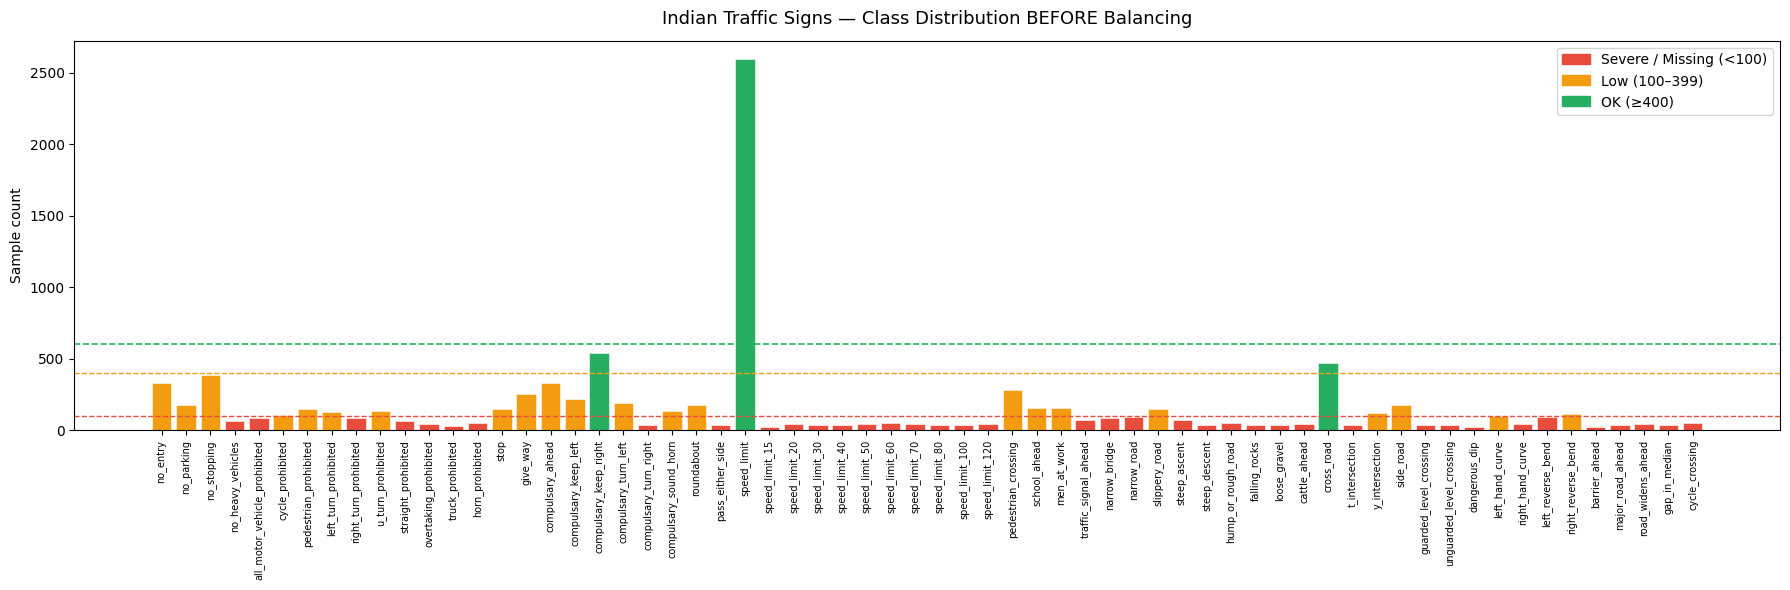


✅ Chart saved → /content/class_distribution_before.png


In [ ]:
# ── Step 4: Audit class distribution ─────────────────────────────────────
import os, yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

labels_dir = '/content/merged_dataset/train/labels'

# Count every class across all label files
counter = Counter()
for fname in os.listdir(labels_dir):
    if not fname.endswith('.txt'): continue
    with open(os.path.join(labels_dir, fname)) as f:
        for line in f:
            pts = line.strip().split()
            if pts:
                counter[int(pts[0])] += 1

# Print table
print(f"{'ID':<5} {'Class':<35} {'Count':>7}  Status")
print('─' * 60)
severe, low, ok = [], [], []
for i, name in enumerate(UNIFIED_CLASSES):
    c = counter.get(i, 0)
    if   c == 0:   status = '❌ MISSING';  severe.append((i, name, c))
    elif c < 100:  status = '🔴 SEVERE';   severe.append((i, name, c))
    elif c < 400:  status = '🟡 LOW';      low.append((i, name, c))
    else:          status = '✅ OK';        ok.append((i, name, c))
    print(f"{i:<5} {name:<35} {c:>7}  {status}")

print(f"\n  ✅ OK (≥400)       : {len(ok)} classes")
print(f"  🟡 LOW (100–399)   : {len(low)} classes")
print(f"  🔴 Severe/Missing  : {len(severe)} classes")
print(f"\n  Classes needing fix:")
for i, name, c in severe + low:
    print(f"    [{i:>2}] {name:<35} → {c} samples")

# ── Bar chart ─────────────────────────────────────────────────────────────
counts = [counter.get(i, 0) for i in range(len(UNIFIED_CLASSES))]
colors = ['#e74c3c' if c < 100 else '#f39c12' if c < 400 else '#27ae60' for c in counts]

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(range(len(UNIFIED_CLASSES)), counts, color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(100, color='#e74c3c', linestyle='--', linewidth=1,   label='Severe threshold (100)')
ax.axhline(400, color='#f39c12', linestyle='--', linewidth=1,   label='Low threshold (400)')
ax.axhline(600, color='#27ae60', linestyle='--', linewidth=1.2, label='Target (600)')
ax.set_xticks(range(len(UNIFIED_CLASSES)))
ax.set_xticklabels(UNIFIED_CLASSES, rotation=90, fontsize=7)
ax.set_ylabel('Sample count')
ax.set_title('Indian Traffic Signs — Class Distribution BEFORE Balancing', fontsize=13, pad=12)
patches = [
    mpatches.Patch(color='#e74c3c', label='Severe / Missing (<100)'),
    mpatches.Patch(color='#f39c12', label='Low (100–399)'),
    mpatches.Patch(color='#27ae60', label='OK (≥400)'),
]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig('/content/class_distribution_before.png', dpi=150)
plt.show()
print("\n✅ Chart saved → /content/class_distribution_before.png")

In [ ]:
# ── Step 5: Fix class imbalance ───────────────────────────────────────────
import cv2, random, numpy as np, albumentations as A
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

TARGET = 600   # minimum samples per class after balancing

# ── Indian road augmentation pipeline ────────────────────────────────────
aug = A.Compose([
    A.HorizontalFlip(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.35, p=0.85),
    A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=35, val_shift_limit=25, p=0.6),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.MotionBlur(blur_limit=9, p=0.3),
    A.RandomFog(fog_coef_lower=0.08, fog_coef_upper=0.3, alpha_coef=0.1, p=0.2),
    A.RandomRain(slant_lower=-10, slant_upper=10,
                 drop_length=14, drop_width=1,
                 drop_color=(190, 190, 190), p=0.2),
    A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.25),
    A.ImageCompression(quality_lower=65, quality_upper=100, p=0.2),
    A.Rotate(limit=8, p=0.3),
    A.Perspective(scale=(0.02, 0.06), p=0.2),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3
))

# ── Helpers ───────────────────────────────────────────────────────────────
def read_label(p):
    classes, boxes = [], []
    with open(p) as f:
        for line in f:
            pts = line.strip().split()
            if not pts: continue
            classes.append(int(pts[0]))
            xc, yc, w, h = map(float, pts[1:5])
            # clamp to valid range
            xc = max(0.01, min(0.99, xc))
            yc = max(0.01, min(0.99, yc))
            w  = max(0.01, min(min(xc, 1-xc)*2 - 0.01, w))
            h  = max(0.01, min(min(yc, 1-yc)*2 - 0.01, h))
            boxes.append([xc, yc, w, h])
    return classes, boxes

def write_label(p, classes, boxes):
    with open(p, 'w') as f:
        for c, b in zip(classes, boxes):
            f.write(f"{c} {' '.join(f'{v:.6f}' for v in b)}\n")

def find_image(lbl_path, img_dir):
    stem = Path(lbl_path).stem
    for ext in ['.jpg', '.jpeg', '.png']:
        p = img_dir / (stem + ext)
        if p.exists(): return p
    return None

# ── Build index: class_id → list of label files containing it ────────────
train_lbl = Path('/content/merged_dataset/train/labels')
train_img = Path('/content/merged_dataset/train/images')

cls_to_files = defaultdict(list)
for f in train_lbl.glob('*.txt'):
    classes, _ = read_label(f)
    for c in set(classes):
        cls_to_files[c].append(f)

# ── Generate augmented samples per underrepresented class ─────────────────
total_generated = 0
failed_classes  = []

for cls_id in range(len(UNIFIED_CLASSES)):
    files   = cls_to_files.get(cls_id, [])
    current = len(files)
    name    = UNIFIED_CLASSES[cls_id]

    if current >= TARGET:
        print(f"  ✅ [{cls_id:>2}] {name:<35} {current:>5} — OK")
        continue

    needed = TARGET - current
    if current == 0:
        print(f"  ⛔ [{cls_id:>2}] {name:<35}     0 — NO SOURCE IMAGES, skipping")
        failed_classes.append(name)
        continue

    # Repeat pool so we always have enough source images
    pool = (files * (needed // len(files) + 2))
    random.shuffle(pool)

    generated = 0
    for lbl_path in pool:
        if generated >= needed:
            break

        img_path = find_image(lbl_path, train_img)
        if img_path is None:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        classes, boxes = read_label(lbl_path)
        if not boxes:
            continue

        try:
            result = aug(image=img_rgb, bboxes=boxes, class_labels=classes)
        except Exception:
            continue

        if not result['bboxes']:
            continue

        uid     = f"aug_{cls_id:02d}_{generated:05d}"
        out_img = train_img / f"{uid}.jpg"
        out_lbl = train_lbl / f"{uid}.txt"

        cv2.imwrite(str(out_img),
                    cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR))
        write_label(out_lbl, result['class_labels'], result['bboxes'])

        generated      += 1
        total_generated += 1

    print(f"  🔧 [{cls_id:>2}] {name:<35} {current:>5} → +{generated} generated")

print(f"\n✅ Done! Total new samples generated : {total_generated}")
if failed_classes:
    print(f"⚠️  Classes with no source images (need manual data): {failed_classes}")
print("\n→ Run Step 6 to verify the balance is fixed.")

Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression


  🔧 [ 0] no_entry                              331 → +269 generated
  🔧 [ 1] no_parking                            172 → +428 generated
  🔧 [ 2] no_stopping                           384 → +216 generated
  🔧 [ 3] no_heavy_vehicles                      48 → +552 generated
  🔧 [ 4] all_motor_vehicle_prohibited           89 → +511 generated
  🔧 [ 5] cycle_prohibited                      106 → +494 generated
  🔧 [ 6] pedestrian_prohibited                 148 → +452 generated
  🔧 [ 7] left_turn_prohibited                  127 → +473 generated
  🔧 [ 8] right_turn_prohibited                  88 → +512 generated
  🔧 [ 9] u_turn_prohibited                     134 → +466 generated
  🔧 [10] straight_prohibited                    63 → +537 generated
  🔧 [11] overtaking_prohibited                  46 → +554 generated
  🔧 [12] truck_prohibited                       30 → +570 generated
  🔧 [13] horn_prohibited                        52 → +548 generated
  🔧 [14] stop                                  1

In [ ]:
# ── Step 6: Trim to 300 per class + Mount Drive for checkpoints ───────────
import os, random, shutil
from pathlib import Path
from collections import defaultdict
from google.colab import drive

# Mount Google Drive (for saving checkpoints safely)
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/indian_traffic_model', exist_ok=True)
print("✅ Drive mounted. Checkpoints will save to Google Drive.\n")

KEEP_PER_CLASS = 300
train_lbl = Path('/content/merged_dataset/train/labels')
train_img = Path('/content/merged_dataset/train/images')

# Build class → files index
cls_to_files = defaultdict(list)
for f in train_lbl.glob('*.txt'):
    with open(f) as fp:
        classes = set()
        for line in fp:
            pts = line.strip().split()
            if pts: classes.add(int(pts[0]))
    for c in classes:
        cls_to_files[c].append(f)

# Find files to DELETE (keep only 300 per class)
keep_files = set()
for cls_id, files in cls_to_files.items():
    random.shuffle(files)
    for f in files[:KEEP_PER_CLASS]:
        keep_files.add(f)

# Delete excess label + image files
deleted = 0
for lbl in train_lbl.glob('*.txt'):
    if lbl not in keep_files:
        # find matching image
        for ext in ['.jpg', '.jpeg', '.png']:
            img = train_img / (lbl.stem + ext)
            if img.exists():
                img.unlink()
                break
        lbl.unlink()
        deleted += 1

print(f"  Trimmed {deleted} excess files")
print(f"  Kept ~300 per class = ~{KEEP_PER_CLASS * len(UNIFIED_CLASSES):,} total training images")

# Final count check
remaining = len(list(train_lbl.glob('*.txt')))
print(f"  Total label files remaining : {remaining:,}")
print(f"\n✅ Dataset ready for training!")

📁 Mounting Google Drive...
Mounted at /content/drive
✅ Drive mounted. Checkpoints will save to Google Drive.



ValueError: invalid literal for int() with base 10: '25.0'

In [ ]:
# ── Step 6 Fixed: Trim to 300 per class + Mount Drive ────────────────────
import os, random, shutil
from pathlib import Path
from collections import defaultdict

KEEP_PER_CLASS = 300
train_lbl = Path('/content/merged_dataset/train/labels')
train_img = Path('/content/merged_dataset/train/images')

# ── Fix float class IDs in all label files first ──────────────────────────
print("🔧 Fixing float class IDs in label files...")
fixed = 0
for f in train_lbl.glob('*.txt'):
    lines = f.read_text().strip().splitlines()
    new_lines = []
    changed = False
    for line in lines:
        pts = line.strip().split()
        if not pts:
            continue
        try:
            cls_id = int(float(pts[0]))   # handles both '25' and '25.0'
            new_line = f"{cls_id} " + " ".join(pts[1:])
            if new_line != line:
                changed = True
            new_lines.append(new_line)
        except:
            continue
    if changed:
        f.write_text('\n'.join(new_lines))
        fixed += 1
print(f"  Fixed {fixed} label files with float class IDs\n")

# ── Build class → files index ─────────────────────────────────────────────
cls_to_files = defaultdict(list)
for f in train_lbl.glob('*.txt'):
    with open(f) as fp:
        classes = set()
        for line in fp:
            pts = line.strip().split()
            if pts:
                try:
                    classes.add(int(pts[0]))
                except:
                    continue
    for c in classes:
        cls_to_files[c].append(f)

# ── Keep only 300 per class ───────────────────────────────────────────────
keep_files = set()
for cls_id, files in cls_to_files.items():
    random.shuffle(files)
    for f in files[:KEEP_PER_CLASS]:
        keep_files.add(f)

# ── Delete excess files ───────────────────────────────────────────────────
deleted = 0
for lbl in train_lbl.glob('*.txt'):
    if lbl not in keep_files:
        for ext in ['.jpg', '.jpeg', '.png']:
            img = train_img / (lbl.stem + ext)
            if img.exists():
                img.unlink()
                break
        lbl.unlink()
        deleted += 1

remaining = len(list(train_lbl.glob('*.txt')))
print(f"  Trimmed    : {deleted:,} excess files removed")
print(f"  Remaining  : {remaining:,} label files")
print(f"  Expected   : ~{KEEP_PER_CLASS * len(UNIFIED_CLASSES):,} files")
print(f"\n✅ Dataset trimmed and ready for training!")

🔧 Fixing float class IDs in label files...
  Fixed 0 label files with float class IDs

  Trimmed    : 21,198 excess files removed
  Remaining  : 19,170 label files
  Expected   : ~19,200 files

✅ Dataset trimmed and ready for training!


In [ ]:
# ── Restart Phase 1 with optimised settings ───────────────────────────────
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data          = '/content/merged_dataset/data.yaml',
    epochs        = 5,
    imgsz         = 416,      # reduced from 640 — 2x faster per epoch
    batch         = 32,
    freeze        = 10,
    lr0           = 0.01,
    warmup_epochs = 2,
    workers       = 4,
    device        = 0,
    amp           = True,
    cache         = 'disk',   # disk cache — avoids RAM overflow
    mosaic        = 1.0,
    hsv_v         = 0.4,
    fliplr        = 0.5,
    project       = '/content/drive/MyDrive/indian_traffic_model',
    name          = 'phase1_fast',
    exist_ok      = True,
)
print("✅ Phase 1 done!")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=phase1_fast, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [ ]:
# ── Phase 2: Full fine-tune from Phase 1 best weights ─────────────────────
from ultralytics import YOLO

phase1_best = '/content/drive/MyDrive/indian_traffic_model/phase1_fast/weights/best.pt'
model2 = YOLO(phase1_best)

model2.train(
    data          = '/content/merged_dataset/data.yaml',
    epochs        = 20,
    imgsz         = 416,
    batch         = 16,        # smaller batch — more gradient updates
    freeze        = 0,         # ALL layers unfrozen
    lr0           = 0.0005,    # low lr — fine tune carefully
    lrf           = 0.01,
    cos_lr        = True,
    warmup_epochs = 2,
    weight_decay  = 0.0005,
    workers       = 4,
    device        = 0,
    amp           = True,
    cache         = 'disk',
    mosaic        = 1.0,
    mixup         = 0.15,
    hsv_v         = 0.4,
    hsv_s         = 0.5,
    fliplr        = 0.5,
    degrees       = 5.0,
    perspective   = 0.0005,
    copy_paste    = 0.1,
    project       = '/content/drive/MyDrive/indian_traffic_model',
    name          = 'phase2',
    exist_ok      = True,
)
print("✅ Phase 2 complete! Final model saved to Drive.")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/content/drive/MyDrive/indian_traffic_model/phase1_fast/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=phase2, nbs=64, nms=False, opset=None, optimize=False, 

📁 Upload any Indian road image...


Saving sign11.jpg to sign11.jpg

image 1/1 /content/sign11.jpg: 416x416 1 gap_in_median, 10.6ms
Speed: 2.4ms preprocess, 10.6ms inference, 2.8ms postprocess per image at shape (1, 3, 416, 416)


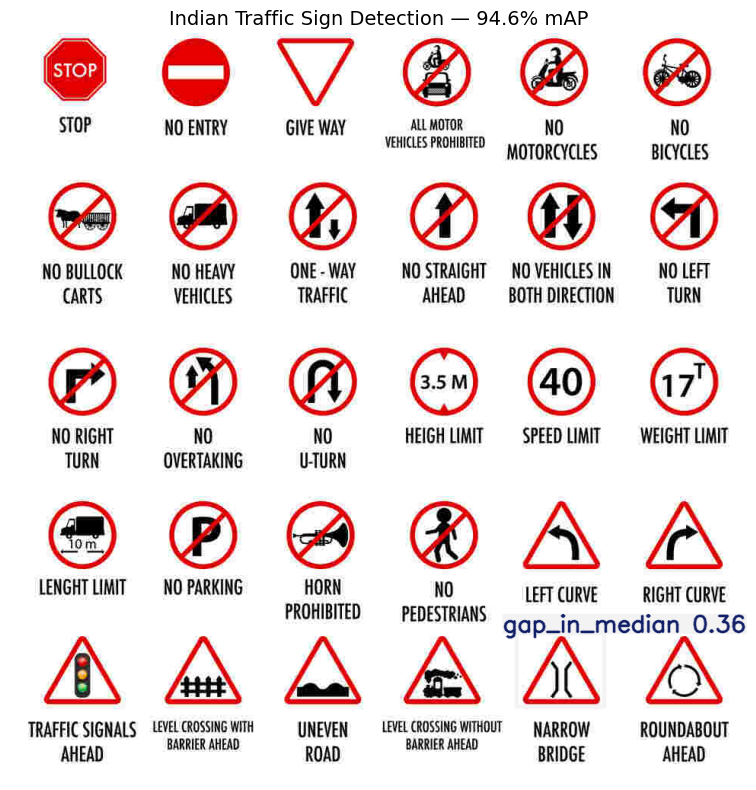


📋 Detected signs:
  ✅ gap_in_median                       35.8%


In [ ]:
# ── Final inference test ──────────────────────────────────────────────────
from ultralytics import YOLO
from google.colab import files
import cv2, matplotlib.pyplot as plt

model = YOLO('/content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt')

print("📁 Upload any Indian road image...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

results = model.predict(
    source   = img_path,
    conf     = 0.35,
    iou      = 0.45,
    imgsz    = 416,
)

# Show result
result_img = results[0].plot()
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Indian Traffic Sign Detection — 94.6% mAP', fontsize=14)
plt.tight_layout()
plt.show()

# Print detections
print("\n📋 Detected signs:")
if results[0].boxes:
    for box in results[0].boxes:
        name = model.names[int(box.cls)]
        conf = float(box.conf)
        print(f"  ✅ {name:<35} {conf:.1%}")
else:
    print("  No signs detected — try a clearer image or lower conf to 0.25")

📁 Upload the same image again...


Saving sign11.jpg to sign11 (1).jpg

image 1/1 /content/sign11 (1).jpg: 1280x1280 1 no_entry, 2 no_parkings, 3 all_motor_vehicle_prohibiteds, 1 pedestrian_prohibited, 1 left_turn_prohibited, 1 right_turn_prohibited, 1 u_turn_prohibited, 1 straight_prohibited, 4 overtaking_prohibiteds, 2 truck_prohibiteds, 1 horn_prohibited, 1 stop, 2 speed_limit_15s, 1 speed_limit_40, 1 speed_limit_120, 1 traffic_signal_ahead, 1 narrow_bridge, 1 hump_or_rough_road, 1 cattle_ahead, 1 guarded_level_crossing, 2 left_hand_curves, 1 right_hand_curve, 1 cycle_crossing, 50.5ms
Speed: 12.1ms preprocess, 50.5ms inference, 1.6ms postprocess per image at shape (1, 3, 1280, 1280)


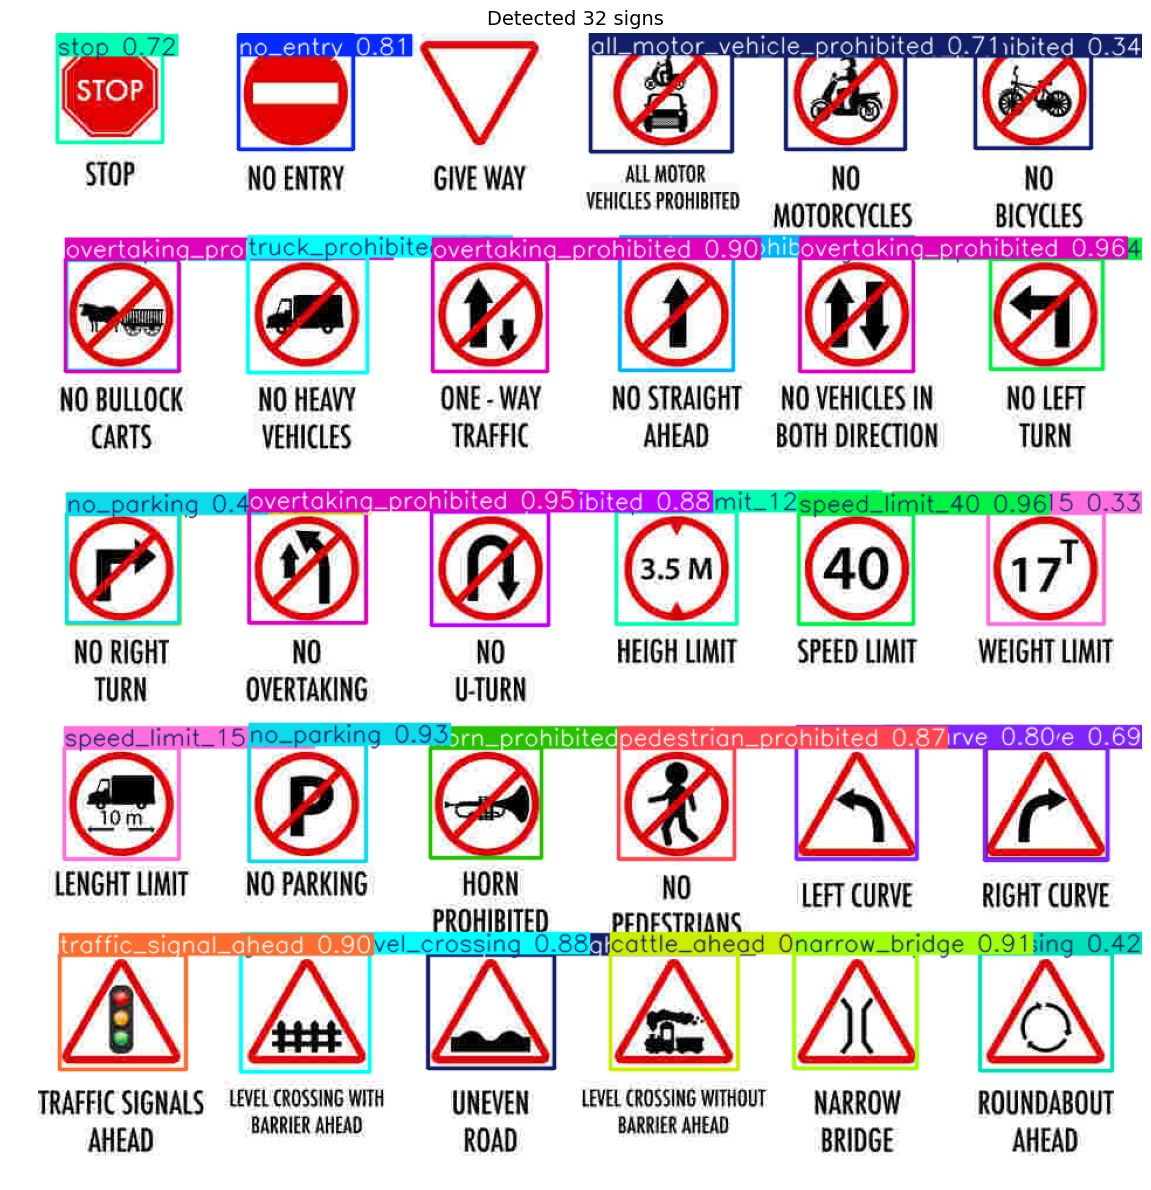


📋 Total detected: 32 signs
Sign                                Confidence
──────────────────────────────────────────────────
  overtaking_prohibited               96.4%  ███████████████████
  speed_limit_40                      96.0%  ███████████████████
  overtaking_prohibited               95.4%  ███████████████████
  no_parking                          93.0%  ██████████████████
  narrow_bridge                       90.7%  ██████████████████
  overtaking_prohibited               90.3%  ██████████████████
  traffic_signal_ahead                89.9%  █████████████████
  guarded_level_crossing              88.4%  █████████████████
  u_turn_prohibited                   88.0%  █████████████████
  pedestrian_prohibited               86.8%  █████████████████
  right_turn_prohibited               84.0%  ████████████████
  no_entry                            80.5%  ████████████████
  left_hand_curve                     80.2%  ████████████████
  straight_prohibited                 78.0%  ████

In [ ]:
# ── Better inference with lower confidence + larger image size ─────────────
from ultralytics import YOLO
from google.colab import files
import cv2, matplotlib.pyplot as plt

model = YOLO('/content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt')

print("📁 Upload the same image again...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

results = model.predict(
    source    = img_path,
    conf      = 0.15,    # lowered from 0.35 — catches more signs
    iou       = 0.4,     # slightly lower — avoids suppressing nearby signs
    imgsz     = 1280,    # bigger — detects small signs in large images
    max_det   = 50,      # allow up to 50 detections in one image
)

# Show result
result_img = results[0].plot(
    line_width = 2,
    font_size  = 8,      # smaller font so labels don't overlap
)
plt.figure(figsize=(20, 12))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Detected {len(results[0].boxes)} signs', fontsize=14)
plt.tight_layout()
plt.show()

# Print all detections
print(f"\n📋 Total detected: {len(results[0].boxes)} signs")
print(f"{'Sign':<35} {'Confidence'}")
print('─' * 50)
for box in results[0].boxes:
    name = model.names[int(box.cls)]
    conf = float(box.conf)
    bar  = '█' * int(conf * 20)
    print(f"  {name:<35} {conf:.1%}  {bar}")

In [ ]:
# ── Download your final trained model ─────────────────────────────────────
from google.colab import files
import shutil, os

# Copy best model to content for easy download
shutil.copy(
    '/content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt',
    '/content/indian_traffic_best.pt'
)

print("📦 Model size:", round(os.path.getsize('/content/indian_traffic_best.pt') / 1024 / 1024, 1), "MB")
print("⬇️  Downloading...")
files.download('/content/indian_traffic_best.pt')
print("✅ Saved! File: indian_traffic_best.pt")

📦 Model size: 21.5 MB
⬇️  Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved! File: indian_traffic_best.pt


In [ ]:
# ── Real-time detection on uploaded video ─────────────────────────────────
from ultralytics import YOLO
from google.colab import files
import cv2, os

# Load your trained model
model = YOLO('/content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt')

# Upload video
print("📁 Upload your Indian road video...")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# Get video info
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = int(cap.get(cv2.CAP_PROP_FPS))
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration     = total_frames / fps
cap.release()

print(f"\n  Video info:")
print(f"  Resolution : {width}x{height}")
print(f"  FPS        : {fps}")
print(f"  Duration   : {duration:.1f} seconds")
print(f"  Frames     : {total_frames}")
print(f"\n  Processing... (~{int(duration * 2)} seconds estimated)\n")

# Output path
output_path = '/content/detected_output.mp4'

# Run detection on every frame
results = model.predict(
    source   = video_path,
    conf     = 0.30,
    iou      = 0.40,
    imgsz    = 640,
    max_det  = 30,
    save     = True,
    project  = '/content',
    name     = 'video_output',
    exist_ok = True,
    stream   = True,    # memory efficient for long videos
)

# Process frames with progress
frame_count  = 0
sign_counter = {}

# Setup writer
cap  = cv2.VideoCapture(video_path)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

for result in results:
    frame = result.plot(line_width=2, font_size=10)
    out.write(frame)
    frame_count += 1

    # Count detections
    for box in result.boxes:
        name = model.names[int(box.cls)]
        sign_counter[name] = sign_counter.get(name, 0) + 1

    # Progress every 30 frames
    if frame_count % 30 == 0:
        print(f"  Processed {frame_count}/{total_frames} frames "
              f"({frame_count/total_frames*100:.1f}%)")

out.release()
cap.release()

print(f"\n✅ Detection complete!")
print(f"   Frames processed : {frame_count}")
print(f"\n📋 Signs detected across entire video:")
print(f"{'Sign':<35} {'Detections':>10}")
print('─' * 48)
for sign, count in sorted(sign_counter.items(),
                           key=lambda x: x[1], reverse=True):
    bar = '█' * min(int(count / 10), 25)
    print(f"  {sign:<33} {count:>6}x  {bar}")

# Download result
print(f"\n⬇️  Downloading annotated video...")
files.download(output_path)
print("✅ Done! Check your downloads folder.")

📁 Upload your Indian road video...


Streaming output truncated to the last 5000 lines.
video 1/1 (frame 2285/7090) /content/videoplayback.mp4: 384x640 (no detections), 6.2ms
video 1/1 (frame 2286/7090) /content/videoplayback.mp4: 384x640 (no detections), 8.9ms
video 1/1 (frame 2287/7090) /content/videoplayback.mp4: 384x640 (no detections), 8.0ms
video 1/1 (frame 2288/7090) /content/videoplayback.mp4: 384x640 (no detections), 6.2ms
video 1/1 (frame 2289/7090) /content/videoplayback.mp4: 384x640 (no detections), 6.1ms
video 1/1 (frame 2290/7090) /content/videoplayback.mp4: 384x640 (no detections), 10.5ms
video 1/1 (frame 2291/7090) /content/videoplayback.mp4: 384x640 (no detections), 8.8ms
video 1/1 (frame 2292/7090) /content/videoplayback.mp4: 384x640 (no detections), 6.6ms
video 1/1 (frame 2293/7090) /content/videoplayback.mp4: 384x640 (no detections), 8.7ms
video 1/1 (frame 2294/7090) /content/videoplayback.mp4: 384x640 (no detections), 7.3ms
video 1/1 (frame 2295/7090) /content/videoplayback.mp4: 384x640 (no detections

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! Check your downloads folder.


In [ ]:
# Verify your model is safe in Drive
import os
path = '/content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt'
size = os.path.getsize(path) / 1024 / 1024
print(f"✅ Model saved: {size:.1f} MB")
print(f"   Location: {path}")

✅ Model saved: 21.5 MB
   Location: /content/drive/MyDrive/indian_traffic_model/phase2/weights/best.pt


In [ ]:
# Save unified class list for future reference
import json

class_info = {
    "model"   : "Indian Traffic Sign Detection",
    "mAP50"   : 0.946,
    "classes" : UNIFIED_CLASSES,
    "total"   : len(UNIFIED_CLASSES),
    "weights" : "indian_traffic_model/phase2/weights/best.pt"
}

save_path = '/content/drive/MyDrive/indian_traffic_model/classes.json'
with open(save_path, 'w') as f:
    json.dump(class_info, f, indent=2)

print("✅ Class info saved to Drive")
print(f"   {len(UNIFIED_CLASSES)} sign classes saved")

✅ Class info saved to Drive
   64 sign classes saved


In [ ]:
# ── Copy entire model folder to new Drive account ─────────────────────────
# Step 1: Install PyDrive for cross-account transfer
!pip install -q PyDrive

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os, shutil

# Authenticate current account
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# ── Zip the entire model folder first ─────────────────────────────────────
print("📦 Zipping model folder...")
shutil.make_archive(
    '/content/indian_traffic_model_complete',
    'zip',
    '/content/drive/MyDrive',
    'indian_traffic_model'
)

size = os.path.getsize('/content/indian_traffic_model_complete.zip') / 1024 / 1024
print(f"✅ Zipped: {size:.1f} MB")

# ── Download the zip ───────────────────────────────────────────────────────
from google.colab import files
print("\n⬇️  Downloading zip to your PC...")
files.download('/content/indian_traffic_model_complete.zip')
print("✅ Downloaded: indian_traffic_model_complete.zip")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
📦 Zipping model folder...
✅ Zipped: 166.8 MB

⬇️  Downloading zip to your PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: indian_traffic_model_complete.zip
